# FINAL PROJECT — Programming for Data Science
## Part 2: Data Manipulation and Visualization

**Group members:**
- Mohammed Ahajjam Ziggaf Kanjaa
- Rodrigo Peña Vigil
- Sergio Martínez Lahoz
- Víctor Ramírez Castaño
- Younes Labvhiri

**Data sources (generated in Part 1):**
- `players.csv`  : per-game stats for all NBA players (2023-24 seWason)
- `salaries.csv` : current season salaries (y1) per player
- `standings.csv`: historical win/loss record per franchise

**Questions:**
- Q1 — Is there a relationship between salary and scoring (PTS)?
- Q2 — Which teams have the best cost-efficiency? (total wins / total salary)
- Q3 — Which franchises pay the most by position?
- Q4 — Do the highest scorers earn more than the rest?

---
## 0. Global Style

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

---
## 1. Load Data

In [2]:
print("Loading data...")

players   = pd.read_csv("players.csv")
salaries  = pd.read_csv("salaries.csv")
standings = pd.read_csv("standings.csv")

print(f"  players  : {len(players)} rows")
print(f"  salaries : {len(salaries)} rows")
print(f"  standings: {len(standings)} rows")

Loading data...
  players  : 721 rows
  salaries : 522 rows
  standings: 30 rows


---
## 2. Data Treatment

### 2.1 Null Analysis

In [3]:
# See how many nulls we have in each dataset, and where they are located
files = {
    "players.csv":  players,
    "salaries.csv": salaries,
    "standings.csv": standings,
}

for name, df in files.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Total nulls: {df.isnull().sum().sum()}")
    print("\nNulls by column:")
    print(df.isnull().sum())


players.csv
-----------
Total nulls: 3

Nulls by column:
player     0
pos        2
age        0
team_id    1
g          0
mp         0
pts        0
trb        0
ast        0
fg_pct     0
fg3_pct    0
efg_pct    0
stl        0
blk        0
tov        0
dtype: int64

salaries.csv
------------
Total nulls: 0

Nulls by column:
player     0
team_id    0
y1         0
dtype: int64

standings.csv
-------------
Total nulls: 0

Nulls by column:
Franchise    0
G            0
W            0
L            0
W/L%         0
Plyfs        0
Champ        0
dtype: int64


### 2.2 Fix Nulls in `players.csv`

In [4]:
# See where are the nulls in players.csv in the "pos" column (position)
rows_with_null_pos = players[players["pos"].isnull()]
print(rows_with_null_pos)

# Fix the nulls in the "pos" column where player is "Adama-Alpha Bal"
players.loc[players["player"] == "Adama-Alpha Bal", "pos"] = "SG"
print(players[players["player"] == "Adama-Alpha Bal"])

# Remove the "League Average" row (has null in pos and team_id)
players = players[~players["player"].str.startswith("League Average", na=False)].copy()

              player  pos   age team_id    g    mp  pts  trb  ast  fg_pct  \
416  Adama-Alpha Bal  NaN  22.0     MEM  2.0  29.5  6.0  2.5  2.5   0.286   
720   League Average  NaN   0.0     NaN  0.0   0.0  0.0  0.0  0.0   0.470   

     fg3_pct  efg_pct  stl  blk  tov  
416    0.250    0.357  1.5  0.0  0.0  
720    0.359    0.545  0.0  0.0  0.0  
              player pos   age team_id    g    mp  pts  trb  ast  fg_pct  \
416  Adama-Alpha Bal  SG  22.0     MEM  2.0  29.5  6.0  2.5  2.5   0.286   

     fg3_pct  efg_pct  stl  blk  tov  
416     0.25    0.357  1.5  0.0  0.0  


### 2.3 Deduplicate Multi-Team Players

In [5]:
# Players that played in different teams during the season appear multiple times
# with the same name but different team_id
players["is_multiTM"] = players["team_id"].isin(["2TM", "3TM"])
players_dedup = (
    players.sort_values(["player", "is_multiTM"], ascending=[True, False])
           .drop_duplicates(subset="player", keep="first")
           .drop(columns="is_multiTM")
)
print(f"  Players after deduplication: {len(players_dedup)}")

  Players after deduplication: 574


### 2.4 Merge Players + Salaries

In [6]:
df = players_dedup.merge(salaries, on="player", how="inner")

# team_id appears in both CSVs → pandas adds _x / _y suffixes; keep players' version
df.rename(columns={"team_id_x": "team_id"}, inplace=True)
df.drop(columns=["team_id_y"], errors="ignore", inplace=True)
print(f"  After merge players+salaries: {len(df)} players")

  After merge players+salaries: 502 players


### 2.5 Team-Level Salary Table & Franchise Mapping

In [7]:
# Build a team-level salary table
team_salary = (
    salaries.groupby("team_id")["y1"]
            .sum()
            .reset_index()
            .rename(columns={"y1": "total_salary"})
)

# Map franchise names -> team abbreviations for the standings join
FRANCHISE_TO_ID = {
    "Atlanta Hawks":          "ATL",
    "Boston Celtics":         "BOS",
    "Brooklyn Nets":          "BRK",
    "Charlotte Hornets":      "CHO",
    "Chicago Bulls":          "CHI",
    "Cleveland Cavaliers":    "CLE",
    "Dallas Mavericks":       "DAL",
    "Denver Nuggets":         "DEN",
    "Detroit Pistons":        "DET",
    "Golden State Warriors":  "GSW",
    "Houston Rockets":        "HOU",
    "Indiana Pacers":         "IND",
    "Los Angeles Clippers":   "LAC",
    "Los Angeles Lakers":     "LAL",
    "Memphis Grizzlies":      "MEM",
    "Miami Heat":             "MIA",
    "Milwaukee Bucks":        "MIL",
    "Minnesota Timberwolves": "MIN",
    "New Orleans Pelicans":   "NOP",
    "New York Knicks":        "NYK",
    "Oklahoma City Thunder":  "OKC",
    "Orlando Magic":          "ORL",
    "Philadelphia 76ers":     "PHI",
    "Phoenix Suns":           "PHO",
    "Portland Trail Blazers": "POR",
    "Sacramento Kings":       "SAC",
    "San Antonio Spurs":      "SAS",
    "Toronto Raptors":        "TOR",
    "Utah Jazz":              "UTA",
    "Washington Wizards":     "WAS",
}

standings["team_id"] = standings["Franchise"].map(FRANCHISE_TO_ID)

### 2.6 Feature Engineering

In [8]:
# --- Q1/Q2: Team-level metrics ---
team_df = standings.merge(team_salary, on="team_id", how="inner")
team_df["win_pct"]          = team_df["W/L%"].astype(float)
team_df["salary_per_win"]   = team_df["total_salary"] / team_df["W"]
team_df["total_salary_M"]   = team_df["total_salary"] / 1_000_000
team_df["salary_per_win_M"] = team_df["salary_per_win"] / 1_000_000
print(f"  Team-level table: {len(team_df)} teams")

# --- Q2: Player efficiency score (composite: pts + ast + trb - tov) ---
df["efficiency"] = df["pts"] + df["ast"] + df["trb"] - df["tov"]
df["salary_M"]   = df["y1"] / 1_000_000
df["eff_per_M"]  = df["efficiency"] / df["salary_M"]   # efficiency per $1M

# Add franchise full name to the main dataframe
id_to_franchise = {v: k for k, v in FRANCHISE_TO_ID.items()}
df["franchise"] = df["team_id"].map(id_to_franchise)
print(f"  Franchises mapped: {df['franchise'].notna().sum()} / {len(df)} players")

# --- Q3: Average salary per franchise × position ---
POSITIONS  = ["PG", "SG", "SF", "PF", "C"]
POS_LABELS = {
    "PG": "Point Guard",
    "SG": "Shooting Guard",
    "SF": "Small Forward",
    "PF": "Power Forward",
    "C":  "Center",
}

df_q1 = df[df["pos"].isin(POSITIONS) & df["franchise"].notna()].copy()
avg_salary = (
    df_q1.groupby(["franchise", "pos"])["salary_M"]
         .mean()
         .reset_index()
         .rename(columns={"salary_M": "avg_salary_M"})
)

# --- Q4: Top 20 scorers vs rest ---
TOP_N = 20
df_sorted    = df.sort_values("pts", ascending=False).reset_index(drop=True)
top_scorers2 = df_sorted.head(TOP_N).copy()
rest2        = df_sorted.iloc[TOP_N:].copy()

top_scorers2["group"] = f"Top {TOP_N} scorers"
rest2["group"]        = "Rest of players"
df_q2 = pd.concat([top_scorers2, rest2], ignore_index=True)

  Team-level table: 30 teams
  Franchises mapped: 421 / 502 players


---
## 3. Data Visualization

### Q1 — Is there a relationship between salary and scoring (PTS)?

Plotting Q1: Salary vs Points...


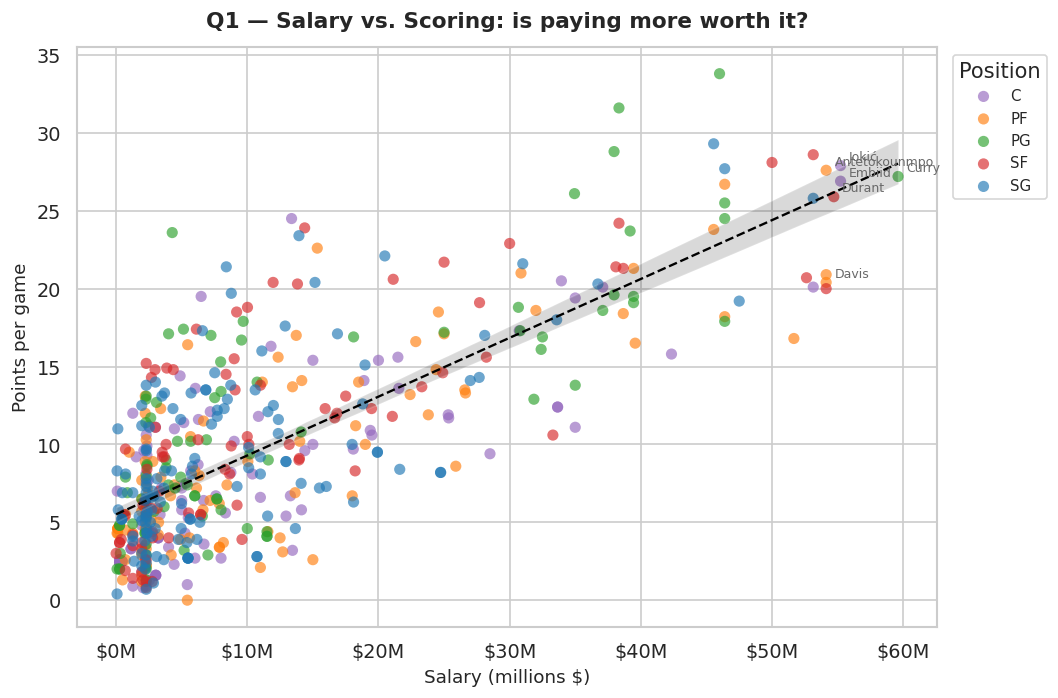

  Saved: q1_salary_vs_pts.png


In [9]:
print("Plotting Q1: Salary vs Points...")

fig, ax = plt.subplots(figsize=(9, 6))

# Colour by position
positions = df["pos"].unique()
palette   = sns.color_palette("tab10", n_colors=len(positions))
pos_color = dict(zip(positions, palette))

for pos, grp in df.groupby("pos"):
    ax.scatter(
        grp["salary_M"], grp["pts"],
        label=pos, color=pos_color[pos],
        alpha=0.65, edgecolors="none", s=45
    )

# Regression line (all positions combined)
sns.regplot(
    data=df, x="salary_M", y="pts",
    scatter=False, ax=ax,
    line_kws={"color": "black", "linewidth": 1.4, "linestyle": "--"},
    ci=95
)

# Annotate top earners
top = df.nlargest(6, "y1")
for _, row in top.iterrows():
    ax.annotate(
        row["player"].split()[-1],
        xy=(row["salary_M"], row["pts"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7.5, color="dimgray"
    )

ax.set_xlabel("Salary (millions $)", fontsize=11)
ax.set_ylabel("Points per game", fontsize=11)
ax.set_title(
    "Q1 — Salary vs. Scoring: is paying more worth it?",
    fontsize=13, fontweight="bold", pad=12
)
ax.legend(title="Position", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))

plt.tight_layout()
plt.savefig("q1_salary_vs_pts.png", bbox_inches="tight")
plt.show()
print("  Saved: q1_salary_vs_pts.png")

### Q2 — Which teams have the best cost-efficiency? (total wins / total salary)

Plotting Q2: Team cost-efficiency...


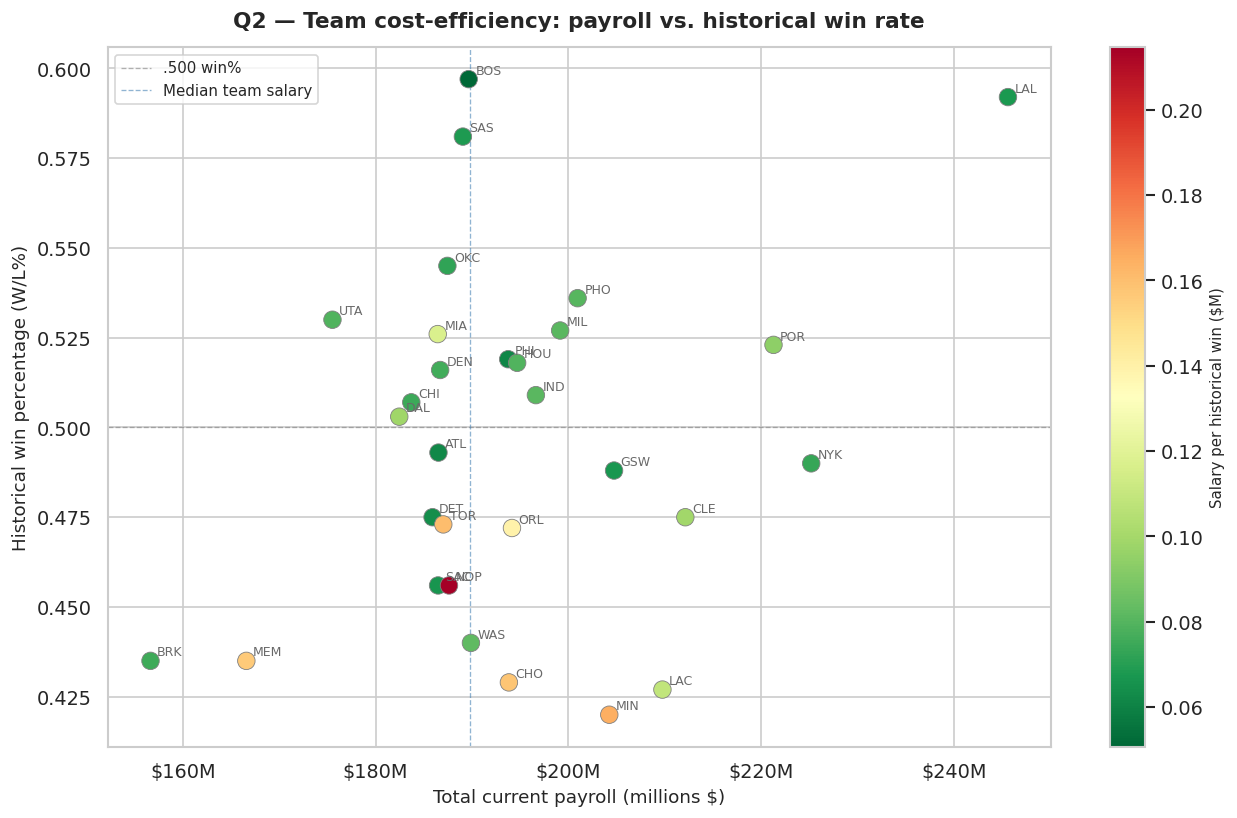

  Saved: q2_team_cost_efficiency.png


In [10]:
print("Plotting Q2: Team cost-efficiency...")

team_sorted = team_df.sort_values("win_pct", ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    team_sorted["total_salary_M"],
    team_sorted["win_pct"],
    c=team_sorted["salary_per_win_M"],
    cmap="RdYlGn_r",
    s=110, edgecolors="gray", linewidths=0.5, zorder=3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Salary per historical win ($M)", fontsize=9)

# Label every team
for _, row in team_sorted.iterrows():
    ax.annotate(
        row["team_id"],
        xy=(row["total_salary_M"], row["win_pct"]),
        xytext=(4, 3), textcoords="offset points",
        fontsize=7.5, color="dimgray"
    )

# Reference lines: median salary and .500 win pct
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6, label=".500 win%")
ax.axvline(
    team_sorted["total_salary_M"].median(), color="steelblue", linewidth=0.8,
    linestyle="--", alpha=0.6, label="Median team salary"
)

ax.set_xlabel("Total current payroll (millions $)", fontsize=11)
ax.set_ylabel("Historical win percentage (W/L%)", fontsize=11)
ax.set_title(
    "Q2 — Team cost-efficiency: payroll vs. historical win rate",
    fontsize=13, fontweight="bold", pad=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("q2_team_cost_efficiency.png", bbox_inches="tight")
plt.show()
print("  Saved: q2_team_cost_efficiency.png")

### Q3 — Which franchises pay the most by position?

Plotting Q3: Salary by franchise and position...


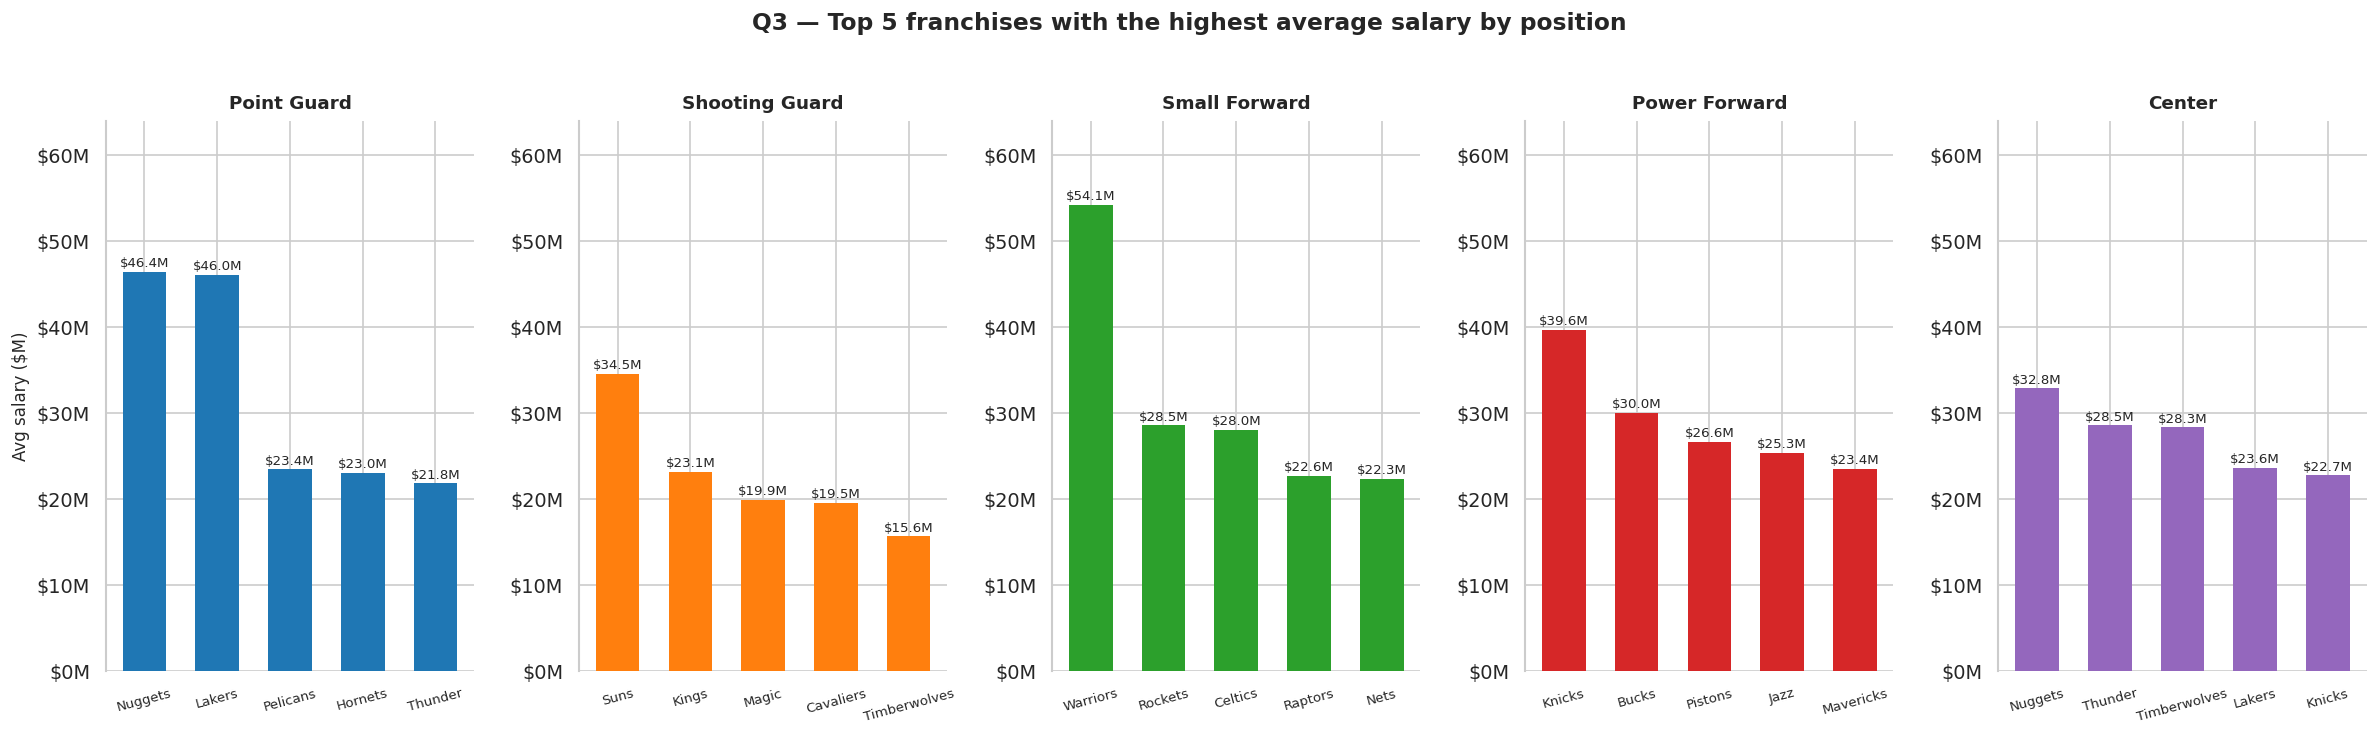

  Saved: q3_salary_by_franchise_position.png


In [11]:
print("Plotting Q3: Salary by franchise and position...")

fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=False)
palette = sns.color_palette("tab10", 5)

for ax, (pos, color) in zip(axes, zip(POSITIONS, palette)):
    data = (
        avg_salary[avg_salary["pos"] == pos]
        .sort_values("avg_salary_M", ascending=False)
        .head(5)
    )

    # Short team name for the x-axis (last word of franchise name)
    data["short"] = data["franchise"].str.split().str[-1]

    bars = ax.bar(
        data["short"], data["avg_salary_M"],
        color=color, edgecolor="none", width=0.6
    )

    # Value label on top of each bar
    for bar, val in zip(bars, data["avg_salary_M"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"${val:.1f}M",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_title(POS_LABELS[pos], fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Avg salary ($M)" if pos == "PG" else "", fontsize=10)
    ax.tick_params(axis="x", labelsize=8, rotation=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
    ax.set_ylim(0, avg_salary["avg_salary_M"].max() * 1.18)
    sns.despine(ax=ax, left=False, bottom=True)

fig.suptitle(
    "Q3 — Top 5 franchises with the highest average salary by position",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("q3_salary_by_franchise_position.png", bbox_inches="tight")
plt.show()
print("  Saved: q3_salary_by_franchise_position.png")

### Q4 — Do the highest scorers earn more than the rest?

Plotting Q4: Top scorers vs salary...


/tmp/ipykernel_18837/1054815771.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_18837/1054815771.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


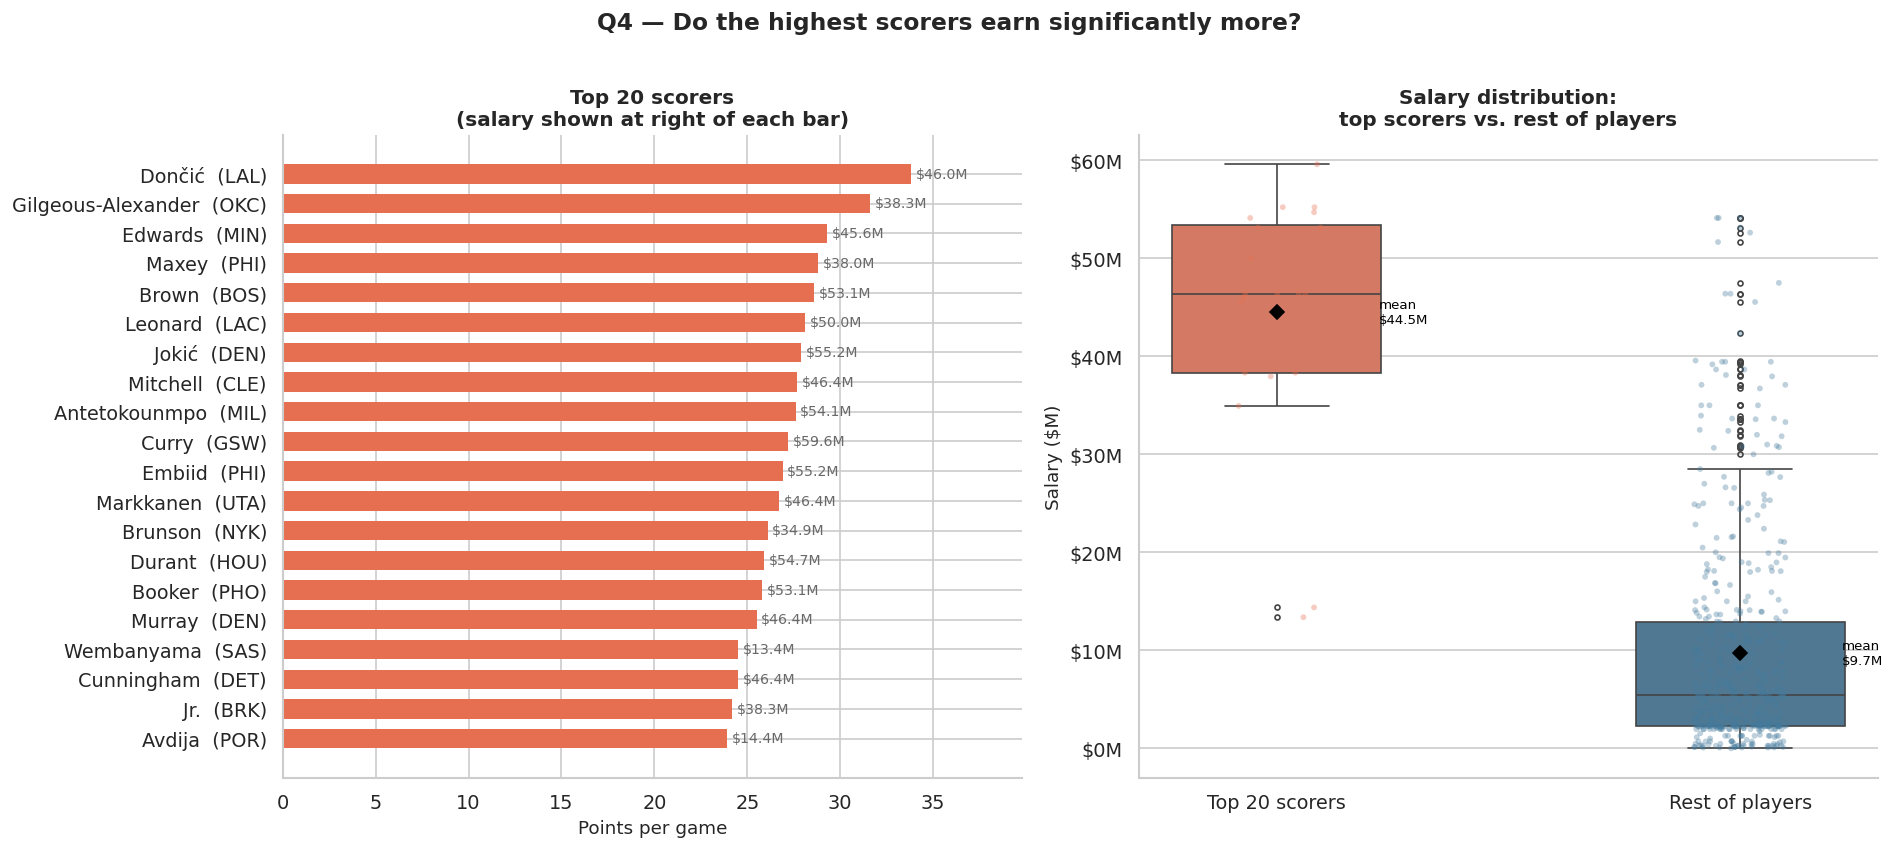

  Saved: q4_top_scorers_vs_salary.png


In [12]:
print("Plotting Q4: Top scorers vs salary...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

COLOR_TOP  = "#E76F51"
COLOR_REST = "#457B9D"

# ── Plot A: horizontal bar chart — top 20 scorers ranked by PTS/G ──────────
# Reverse so highest scorer is at the top
top_plot = top_scorers2.sort_values("pts").copy()
top_plot["label"] = top_plot.apply(
    lambda r: f"{r['player'].split()[-1]}  ({r['team_id']})", axis=1
)

bars = axes[0].barh(
    top_plot["label"], top_plot["pts"],
    color=COLOR_TOP, edgecolor="none", height=0.65
)

# Salary annotation at the end of each bar
for bar, (_, row) in zip(bars, top_plot.iterrows()):
    axes[0].text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"${row['salary_M']:.1f}M",
        va="center", fontsize=8.5, color="dimgray"
    )

axes[0].set_xlabel("Points per game", fontsize=11)
axes[0].set_title(
    f"Top {TOP_N} scorers\n(salary shown at right of each bar)",
    fontsize=12, fontweight="bold"
)
axes[0].set_xlim(0, top_plot["pts"].max() + 6)
sns.despine(ax=axes[0], left=False, bottom=False)

# ── Plot B: box plot — salary distribution, top scorers vs. rest ───────────
sns.boxplot(
    data=df_q2, x="group", y="salary_M",
    palette={f"Top {TOP_N} scorers": COLOR_TOP, "Rest of players": COLOR_REST},
    width=0.45, linewidth=1, fliersize=3,
    order=[f"Top {TOP_N} scorers", "Rest of players"],
    ax=axes[1]
)

# Overlay individual points (jittered) to show distribution
sns.stripplot(
    data=df_q2, x="group", y="salary_M",
    palette={f"Top {TOP_N} scorers": COLOR_TOP, "Rest of players": COLOR_REST},
    order=[f"Top {TOP_N} scorers", "Rest of players"],
    alpha=0.35, size=3.5, jitter=True, ax=axes[1]
)

# Add mean markers
for i, grp in enumerate([f"Top {TOP_N} scorers", "Rest of players"]):
    mean_val = df_q2[df_q2["group"] == grp]["salary_M"].mean()
    axes[1].plot(i, mean_val, marker="D", color="black", markersize=6, zorder=5)
    axes[1].text(
        i + 0.22, mean_val,
        f"mean\n${mean_val:.1f}M",
        va="center", fontsize=8, color="black"
    )

axes[1].set_xlabel("")
axes[1].set_ylabel("Salary ($M)", fontsize=11)
axes[1].set_title(
    "Salary distribution:\ntop scorers vs. rest of players",
    fontsize=12, fontweight="bold"
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
sns.despine(ax=axes[1])

fig.suptitle(
    "Q4 — Do the highest scorers earn significantly more?",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("q4_top_scorers_vs_salary.png", bbox_inches="tight")
plt.show()
print("  Saved: q4_top_scorers_vs_salary.png")

---
## 4. Summary Tables

In [13]:
with open("summary_tables.txt", "w", encoding="utf-8") as f:

    # Q1 table
    f.write("\n" + "="*60 + "\n")
    f.write("SUMMARY — Q1: Top 10 scorers and their salaries\n")
    f.write("="*60 + "\n")
    top_scorers = (
        df[["player", "pos", "team_id", "pts", "salary_M"]]
        .sort_values("pts", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top_scorers.index += 1
    top_scorers.columns = ["Player", "Pos", "Team", "PTS/G", "Salary ($M)"]
    top_scorers["Salary ($M)"] = top_scorers["Salary ($M)"].round(1)
    f.write(top_scorers.to_string())
    f.write("\n\n")

    # Q2 table
    f.write("="*60 + "\n")
    f.write("SUMMARY — Q2: Teams sorted by salary per historical win\n")
    f.write("="*60 + "\n")
    team_summary = (
        team_df[["Franchise", "W", "win_pct", "total_salary_M", "salary_per_win_M"]]
        .sort_values("salary_per_win_M")
        .reset_index(drop=True)
    )
    team_summary.index += 1
    team_summary.columns = ["Franchise", "W (hist.)", "W%", "Payroll ($M)", "$/Win ($M)"]
    team_summary["Payroll ($M)"] = team_summary["Payroll ($M)"].round(1)
    team_summary["$/Win ($M)"]   = team_summary["$/Win ($M)"].round(4)
    team_summary["W%"]           = team_summary["W%"].round(3)
    f.write(team_summary.to_string())
    f.write("\n\n")

    # Q3 table
    f.write("="*65 + "\n")
    f.write("Q3 TABLE — Top 5 franchises by avg salary for each position\n")
    f.write("="*65 + "\n")
    for pos in POSITIONS:
        data = (
            avg_salary[avg_salary["pos"] == pos]
            .sort_values("avg_salary_M", ascending=False)
            .head(5)
            .reset_index(drop=True)
        )
        data.index += 1
        data.columns = ["Franchise", "Pos", "Avg salary ($M)"]
        data["Avg salary ($M)"] = data["Avg salary ($M)"].round(2)
        f.write(f"\n{POS_LABELS[pos]}\n")
        f.write(data[["Franchise", "Avg salary ($M)"]].to_string())
        f.write("\n")

    # Q4 table
    f.write("\n" + "="*55 + "\n")
    f.write(f"Q4 TABLE — Top {TOP_N} scorers and their salaries\n")
    f.write("="*55 + "\n")
    table_q4 = (
        top_scorers2[["player", "pos", "team_id", "pts", "salary_M"]]
        .sort_values("pts", ascending=False)
        .reset_index(drop=True)
    )
    table_q4.index += 1
    table_q4.columns = ["Player", "Pos", "Team", "PTS/G", "Salary ($M)"]
    table_q4["Salary ($M)"] = table_q4["Salary ($M)"].round(1)
    f.write(table_q4.to_string())
    f.write("\n\n")

    mean_top  = top_scorers2["salary_M"].mean()
    mean_rest = rest2["salary_M"].mean()
    f.write(f"Avg salary — top {TOP_N} scorers : ${mean_top:.1f}M\n")
    f.write(f"Avg salary — rest of players    : ${mean_rest:.1f}M\n")
    f.write(
        f"Difference                      : ${mean_top - mean_rest:.1f}M "
        f"({(mean_top/mean_rest - 1)*100:.0f}% more)\n"
    )

print("Saved: summary_tables.txt")
print("\nDone. All plots saved as PNG files in the current directory.")

Saved: summary_tables.txt

Done. All plots saved as PNG files in the current directory.
